# Feature Importance Chart
Generate a horizontal bar chart showing the importance of each feature in the Random Forest model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# feature importance values from the trained Random Forest
features    = ['rate_of_change', 'std_distance', 'range_distance',
               'mean_distance',  'presence_duration']
importances = [0.346, 0.268, 0.226, 0.161, 0.000]

# sort descending so most important is at the top
order         = np.argsort(importances)[::-1]
features_s    = [features[i]    for i in order]
importances_s = [importances[i] for i in order]

# nicer display labels
labels = {
    'rate_of_change':    'Rate of Change',
    'std_distance':      'Std Distance',
    'range_distance':    'Range Distance',
    'mean_distance':     'Mean Distance',
    'presence_duration': 'Presence Duration',
}
feat_labels = [labels[f] for f in features_s]

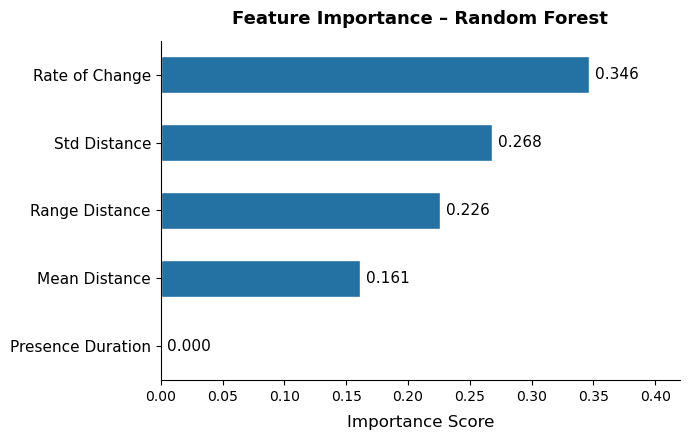

Saved feature_importance.png


In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))

bar_colours = ['#2471A3' if v > 0 else '#BFC9CA' for v in importances_s]
bars = ax.barh(feat_labels, importances_s, color=bar_colours,
               edgecolor='white', height=0.55)

# value labels at the end of each bar
for bar, val in zip(bars, importances_s):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=11)

ax.set_xlabel('Importance Score', fontsize=12, labelpad=8)
ax.set_title('Feature Importance – Random Forest', fontsize=13,
             fontweight='bold', pad=12)
ax.set_xlim(0, 0.42)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved feature_importance.png")